In [1]:
import os
from pathlib import Path

# Set target directory
RAW_DATA_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\raw")
if not RAW_DATA_DIR.exists():
    RAW_DATA_DIR = Path("data/raw")

def concise_inspect(base_path: Path):
    if not base_path.exists():
        print(f"Error: Path '{base_path}' does not exist.")
        return

    print("=== DIRECTORY STRUCTURE ===")
    
    # We only want to peek at the columns of ONE data file so we don't spam the terminal
    peeked_data = False
    
    for root, dirs, files in os.walk(base_path):
        level = root.replace(str(base_path), '').count(os.sep)
        indent = ' ' * 4 * level
        folder_name = os.path.basename(root)
        if folder_name:
            print(f"{indent}📁 {folder_name}/")
        
        subindent = ' ' * 4 * (level + 1)
        for file in files:
            ext = Path(file).suffix.lower()
            print(f"{subindent}📄 {file}")
            
            file_path = Path(root) / file
            
            # Print README content
            if "readme" in file.lower():
                print("\n" + "="*50)
                print(f"--- FULL CONTENT OF {file} ---")
                try:
                    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
                        print(f.read().strip())
                except Exception as e:
                    print(f"[Error reading file: {e}]")
                print("="*50 + "\n")
                
            # Peek at exactly ONE data file to get the column headers
            elif ext in ['.csv', '.txt', '.tsv'] and not peeked_data:
                print("\n" + "-"*50)
                print(f"--- HEADERS FOR: {file} ---")
                try:
                    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
                        print(f.readline().strip()) # Line 1 (Headers usually)
                        print(f.readline().strip()) # Line 2 (First row of data)
                    peeked_data = True
                except Exception as e:
                    print(f"[Error reading file: {e}]")
                print("-"*50 + "\n")

if __name__ == "__main__":
    concise_inspect(RAW_DATA_DIR)

=== DIRECTORY STRUCTURE ===
📁 raw/
    📄 CITATION.cff
    📄 README_dataset.md

--- FULL CONTENT OF README_dataset.md ---
﻿# TAMC-PLANTAS derived dataset

This Zenodo package is a derived, attribution-preserving and pipeline-ready dataset
created to support reproducible execution of the TAMC-PLANTAS analysis.

It is based on the public plant electrophysiology source-data package associated with:

Madariaga, D., Arro, D., Irarrázaval, C., Soto, A., Guerra, F., Romero, A.,
Ovalle, F., Fedrigolli, E., DesRosiers, T., Serbe-Kamp, É., & Marzullo, T.
(2024). A library of electrophysiological responses in plants – A model of
transversal education and open science. Plant Signaling & Behavior, 19(1),
2310977.

Associated article:
https://doi.org/10.1080/15592324.2024.2310977

Original source data:
https://figshare.com/s/65447c618656565467e6

Original license:
Creative Commons Attribution 4.0 International (CC BY 4.0)

## What this derived package contains

- data/raw_plants/: plant electrophysio

In [7]:
import os
from pathlib import Path

# Target the raw_plants directory directly based on your last output
RAW_PLANTS_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\raw\TAMC_PLANTAS_DERIVED_DATASET_ZENODO_v1_PIPELINE_READY_LIGHT\data\raw_plants")

def inspect_folders_only(base_path: Path):
    if not base_path.exists():
        print(f"Error: Path '{base_path}' does not exist. Check your folder structure.")
        return

    print("=== PLANT FOLDERS & SUBFOLDERS ===")
    
    for root, dirs, files in os.walk(base_path):
        # Calculate how deep we are relative to raw_plants
        level = root.replace(str(base_path), '').count(os.sep)
        
        # We only want the plant names (level 0) and their direct subfolders (level 1)
        # If you want to see deeper subfolders, change 'level < 2' to 'level < 3'
        if level < 10:
            indent = ' ' * 4 * level
            folder_name = os.path.basename(root)
            
            # Print the root folder name or subfolder names
            if folder_name:
                print(f"{indent}📁 {folder_name}/")
            elif level == 0:
                print(f"📁 raw_plants/")

if __name__ == "__main__":
    inspect_folders_only(RAW_PLANTS_DIR)

=== PLANT FOLDERS & SUBFOLDERS ===
📁 raw_plants/
    📁 Araucaria/
    📁 Capsicum/
        📁 Chile Serbia/
            📁 Chile Plant 1 -burn/
    📁 Cyperus/
        📁 ground branch/
        📁 ground stem/
    📁 Daucus/
    📁 Dionaea/
        📁 Venus - Colegio/
        📁 Venus - Danae/
            📁 trap 1/
            📁 trap 2/
            📁 trap 3/
            📁 trap 4/
            📁 trap 5/
        📁 Venus - ET/
            📁 Trap 1/
            📁 Trap 10/
            📁 Trap 11/
            📁 Trap 12/
            📁 Trap 2 closing/
            📁 Trap 3 closing/
            📁 Trap 4 too young/
            📁 Trap 5 too young/
            📁 Trap 6 one timer/
            📁 Trap 7 long term/
                📁 Contra left/
                📁 Contra middle/
                📁 Contra right/
                📁 Ipsi left/
                📁 Ipsi middle/
                📁 Ipsi right/
            📁 Trap 8/
            📁 Trap 9/
    📁 Drosera/
    📁 Hedera/
        📁 Ivy colegio/
        📁 Ivy danae/
 

In [4]:
import wave
from pathlib import Path

# Target your raw data directory
raw_dir = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\raw")
wav_files = list(raw_dir.rglob("*.wav"))

if wav_files:
    test_wav = wav_files[0] # Grab the first wav file it finds
    test_txt = test_wav.with_name(test_wav.stem + "-events.txt")
    
    print("="*50)
    print(f"🎯 ANALYZING: {test_wav.name}")
    print("="*50)
    
    # Read WAV properties
    with wave.open(str(test_wav), 'rb') as w:
        framerate = w.getframerate()
        frames = w.getnframes()
        channels = w.getnchannels()
        duration = frames / float(framerate)
        
    print(f"📊 Sampling Rate: {framerate} Hz (data points per second)")
    print(f"⏱️ Duration:      {duration:.2f} seconds")
    print(f"📈 Channels:      {channels}")
    
    # Read the matching events file
    if test_txt.exists():
        print("\n📝 EVENT MARKERS:")
        with open(test_txt, 'r') as f:
            print(f.read().strip())
    else:
        print("\n⚠️ No matching events.txt found for this file.")
else:
    print("No .wav files found. Check your directory path!")

🎯 ANALYZING: BYB_Recording_2022-10-14_09.09.29.wav
📊 Sampling Rate: 10000 Hz (data points per second)
⏱️ Duration:      63.54 seconds
📈 Channels:      1

📝 EVENT MARKERS:
# Marker IDs can be arbitrary strings.
# Marker ID,	Time (in s)
1,	12.5090


In [2]:
import os
import shutil
import numpy as np
from pathlib import Path
from scipy.io import wavfile
from scipy.signal import butter, sosfiltfilt

# --- CONFIGURATION ---
RAW_SOLANUM_DIR = Path("../data/raw/TAMC_PLANTAS_DERIVED_DATASET_ZENODO_v1_PIPELINE_READY_LIGHT/data/raw_plants/Solanum")
PROCESSED_DIR = Path("../data/processed/solanum")
HEALTHY_DIR = PROCESSED_DIR / "healthy"
STRESSED_DIR = PROCESSED_DIR / "stressed"

TARGET_SAMPLES = 5000  # Strictly enforce exactly 5,000 points per window

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Filters out extreme room drift and high-frequency static using stable SOS format."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    
    # 'sos' prevents mathematical explosion (overflow) at low frequencies
    sos = butter(order, [low, high], btype='band', output='sos')
    
    return sosfiltfilt(sos, data)

def parse_event_time(txt_path: Path) -> float:
    """Reads the exact stress timestamp from the matching -events.txt file."""
    if not txt_path.exists():
        return None
    try:
        with open(txt_path, 'r', encoding='utf-8', errors='replace') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#') or 'Marker' in line:
                    continue
                parts = line.split(',')
                if len(parts) >= 2:
                    return float(parts[1].strip())
    except Exception as e:
        print(f"Error reading event file {txt_path.name}: {e}")
    return None

def process_wav_file(wav_path: Path):
    print(f"Processing file: {wav_path.name}")
    
    # 1. Read WAV file
    try:
        fs, raw_data = wavfile.read(wav_path)
    except Exception as e:
        print(f"Error reading wav: {e}")
        return

    # Handle multi-channel audio
    if len(raw_data.shape) > 1:
        raw_data = raw_data[:, 0]
        
    # --- THE FIX: Convert to 64-bit float to prevent overflow during math ---
    raw_data = raw_data.astype(np.float64)
        
    # 2. Apply Bandpass Filter (0.5 Hz to 50.0 Hz) & Z-Score Normalization
    try:
        filtered = butter_bandpass_filter(raw_data, 0.5, 50.0, fs=fs)
    except ValueError as e:
        print(f"Filtering error (check sample rate): {e}")
        return
        
    std = np.std(filtered)
    if std == 0:
        print("Warning: Signal standard deviation is zero. Skipping.")
        return
    normalized = (filtered - np.mean(filtered)) / std
    
    # 3. Find matching event text file
    txt_path = wav_path.with_name(wav_path.stem + "-events.txt")
    stress_time = parse_event_time(txt_path)
    
    if stress_time is None:
        print("No clear event marker found. Treating entire file as healthy baseline.")
        chunk_id = 0
        # Step precisely by TARGET_SAMPLES
        for start in range(0, len(normalized) - TARGET_SAMPLES + 1, TARGET_SAMPLES):
            window = normalized[start:start + TARGET_SAMPLES]
            save_path = HEALTHY_DIR / f"{wav_path.stem}_healthy_{chunk_id}.npy"
            np.save(save_path, window)
            chunk_id += 1
        print(f"Saved {chunk_id} healthy chunks.")
        return

    stress_sample_index = int(stress_time * fs)
    print(f"Stress event detected at: {stress_time} seconds (Sample index: {stress_sample_index})")
    
    # 4. Slice Healthy segment (Before stress event)
    healthy_segment = normalized[:stress_sample_index]
    healthy_chunks = 0
    for start in range(0, len(healthy_segment) - TARGET_SAMPLES + 1, TARGET_SAMPLES):
        window = healthy_segment[start:start + TARGET_SAMPLES]
        save_path = HEALTHY_DIR / f"{wav_path.stem}_h_{healthy_chunks}.npy"
        np.save(save_path, window)
        healthy_chunks += 1
        
    # 5. Slice Stressed segment (After stress event)
    stressed_segment = normalized[stress_sample_index:]
    stressed_chunks = 0
    for start in range(0, len(stressed_segment) - TARGET_SAMPLES + 1, TARGET_SAMPLES):
        window = stressed_segment[start:start + TARGET_SAMPLES]
        save_path = STRESSED_DIR / f"{wav_path.stem}_s_{stressed_chunks}.npy"
        np.save(save_path, window)
        stressed_chunks += 1
        
    print(f"Extracted: {healthy_chunks} healthy windows | {stressed_chunks} stressed windows.")

def main():
    if not RAW_SOLANUM_DIR.exists():
        print(f"Error: Path '{RAW_SOLANUM_DIR}' does not exist.")
        return

    # Clear old processed data to prevent mixing shapes and filters
    if PROCESSED_DIR.exists():
        print("Clearing old processed data...")
        shutil.rmtree(PROCESSED_DIR)
        
    HEALTHY_DIR.mkdir(parents=True, exist_ok=True)
    STRESSED_DIR.mkdir(parents=True, exist_ok=True)
    
    print("Scanning Solanum directory for WAV files...")
    wav_files = list(RAW_SOLANUM_DIR.rglob("*.wav"))
    print(f"Found {len(wav_files)} total recordings for Solanum.")
    
    for wav_path in wav_files:
        process_wav_file(wav_path)
        
    print("Data preprocessing and extraction complete!")
    print(f"Processed files saved in: {PROCESSED_DIR.resolve()}")

if __name__ == "__main__":
    main()

Clearing old processed data...
Scanning Solanum directory for WAV files...
Found 21 total recordings for Solanum.
Processing file: Ann Arbor Solanum Stimulus Fire Distance 25mm BYB_Recording_2021-07-28_01.37.37.wav
No clear event marker found. Treating entire file as healthy baseline.
Saved 31 healthy chunks.
Processing file: Ann Arbor Solanum_2 Stimulus Fire Distance 31mm BYB_Recording_2021-07-28_01.09.57.wav
No clear event marker found. Treating entire file as healthy baseline.
Saved 22 healthy chunks.
Processing file: BYB_Recording_2022-10-25_10.47.58.wav
Stress event detected at: 3.6508 seconds (Sample index: 36508)
Extracted: 7 healthy windows | 53 stressed windows.
Processing file: BYB_Recording_2022-10-25_10.53.34.wav
Stress event detected at: 3.5782 seconds (Sample index: 35782)
Extracted: 7 healthy windows | 39 stressed windows.
Processing file: BYB_Recording_2023-01-05_16.43.30.wav
Stress event detected at: 2.5275 seconds (Sample index: 25275)
Extracted: 5 healthy windows | 7

In [3]:
import os
import shutil
import numpy as np
from pathlib import Path
from scipy.io import wavfile
from scipy.signal import butter, sosfiltfilt, find_peaks

# --- CONFIGURATION ---
RAW_SOLANUM_DIR = Path("../data/raw/TAMC_PLANTAS_DERIVED_DATASET_ZENODO_v1_PIPELINE_READY_LIGHT/data/raw_plants/Solanum")
PROCESSED_DIR = Path("../data/processed/solanum")
HEALTHY_DIR = PROCESSED_DIR / "healthy"
STRESSED_DIR = PROCESSED_DIR / "stressed"

# We now want the full 6.5 second window (65,000 samples at 10,000 Hz)
TARGET_SAMPLES = 65000 

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(order, [low, high], btype='band', output='sos')
    return sosfiltfilt(sos, data)

def parse_event_time(txt_path: Path) -> float:
    if not txt_path.exists():
        return None
    try:
        with open(txt_path, 'r', encoding='utf-8', errors='replace') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#') or 'Marker' in line:
                    continue
                parts = line.split(',')
                if len(parts) >= 2:
                    return float(parts[1].strip())
    except Exception as e:
        print(f"Error reading event file {txt_path.name}: {e}")
    return None

def process_wav_file(wav_path: Path):
    print(f"\nProcessing file: {wav_path.name}")
    
    try:
        fs, raw_data = wavfile.read(wav_path)
    except Exception as e:
        print(f"Error reading wav: {e}")
        return

    if len(raw_data.shape) > 1:
        raw_data = raw_data[:, 0]
        
    raw_data = raw_data.astype(np.float64)
        
    try:
        filtered = butter_bandpass_filter(raw_data, 0.5, 50.0, fs=fs)
    except ValueError as e:
        print(f"Filtering error: {e}")
        return
        
    std = np.std(filtered)
    if std == 0:
        return
    normalized = (filtered - np.mean(filtered)) / std
    
    txt_path = wav_path.with_name(wav_path.stem + "-events.txt")
    stress_time = parse_event_time(txt_path)
    
    # ---------------------------------------------------------
    # SCENARIO 1: NO MARKER (Entire file is healthy)
    # ---------------------------------------------------------
    if stress_time is None:
        chunk_id = 0
        for start in range(0, len(normalized) - TARGET_SAMPLES + 1, TARGET_SAMPLES):
            window = normalized[start:start + TARGET_SAMPLES]
            save_path = HEALTHY_DIR / f"{wav_path.stem}_healthy_{chunk_id}.npy"
            np.save(save_path, window)
            chunk_id += 1
        print(f"Saved {chunk_id} healthy chunks (Full waves).")
        return

    # ---------------------------------------------------------
    # SCENARIO 2: STRESS MARKER FOUND
    # ---------------------------------------------------------
    stress_sample_index = int(stress_time * fs)
    search_end_index = min(int((stress_time + 25.0) * fs), len(normalized))
    search_window = normalized[stress_sample_index:search_end_index]
    
    if len(search_window) == 0:
        return
        
    peaks, _ = find_peaks(search_window, height=0.3, distance=5*fs)
    
    if len(peaks) == 0:
        print("No peak found. Discarding to prevent bad data.")
        return
        
    peak_absolute_index = stress_sample_index + peaks[0]
    
    # SLICE 1: TRUE HEALTHY (Before the marker)
    healthy_segment = normalized[:stress_sample_index]
    healthy_chunks = 0
    for start in range(0, len(healthy_segment) - TARGET_SAMPLES + 1, TARGET_SAMPLES):
        window = healthy_segment[start:start + TARGET_SAMPLES]
        save_path = HEALTHY_DIR / f"{wav_path.stem}_h_{healthy_chunks}.npy"
        np.save(save_path, window)
        healthy_chunks += 1
        
    # SLICE 2: TRUE STRESSED (The exact 6.5s wave)
    active_start = int(peak_absolute_index - (3.0 * fs))
    active_end = active_start + TARGET_SAMPLES # Exactly 65,000 samples
    
    stressed_chunks = 0
    if active_start >= 0 and active_end <= len(normalized):
        window = normalized[active_start:active_end]
        save_path = STRESSED_DIR / f"{wav_path.stem}_s_0.npy"
        np.save(save_path, window)
        stressed_chunks += 1
        
    print(f"Extracted: {healthy_chunks} Pure Healthy | {stressed_chunks} Peak Stressed.")

def main():
    if not RAW_SOLANUM_DIR.exists():
        return

    if PROCESSED_DIR.exists():
        shutil.rmtree(PROCESSED_DIR)
        
    HEALTHY_DIR.mkdir(parents=True, exist_ok=True)
    STRESSED_DIR.mkdir(parents=True, exist_ok=True)
    
    wav_files = list(RAW_SOLANUM_DIR.rglob("*.wav"))
    
    for wav_path in wav_files:
        process_wav_file(wav_path)

if __name__ == "__main__":
    main()


Processing file: Ann Arbor Solanum Stimulus Fire Distance 25mm BYB_Recording_2021-07-28_01.37.37.wav
Saved 2 healthy chunks (Full waves).

Processing file: Ann Arbor Solanum_2 Stimulus Fire Distance 31mm BYB_Recording_2021-07-28_01.09.57.wav
Saved 1 healthy chunks (Full waves).

Processing file: BYB_Recording_2022-10-25_10.47.58.wav
Extracted: 0 Pure Healthy | 1 Peak Stressed.

Processing file: BYB_Recording_2022-10-25_10.53.34.wav
Extracted: 0 Pure Healthy | 1 Peak Stressed.

Processing file: BYB_Recording_2023-01-05_16.43.30.wav
Extracted: 0 Pure Healthy | 1 Peak Stressed.

Processing file: BYB_Recording_2023-01-05_16.48.06.wav
Extracted: 0 Pure Healthy | 1 Peak Stressed.

Processing file: BYB_Recording_2022-10-25_11.00.15.wav
Extracted: 0 Pure Healthy | 1 Peak Stressed.

Processing file: BYB_Recording_2022-10-25_11.02.54.wav
Extracted: 0 Pure Healthy | 1 Peak Stressed.

Processing file: BYB_Recording_2023-02-06_22.34.39.wav
Extracted: 0 Pure Healthy | 1 Peak Stressed.

Processing f

# RAW 1

In [1]:
import pandas as pd
from pathlib import Path

# --- 1. SETUP PATHS ---
# Using raw strings (r"") for Windows file paths to prevent slash errors
DATA_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\raw1")
CSV_PATH = DATA_DIR / "plant_stress_sound_dataset.csv" # Assuming it is saved as a .csv

def run_eda():
    if not CSV_PATH.exists():
        print(f"[ERROR] Could not find the dataset at {CSV_PATH}")
        return

    # --- 2. LOAD & CLEAN DATA ---
    print(f"Loading dataset from {CSV_PATH.name}...\n")
    df = pd.read_csv(CSV_PATH)
    
    # Fix the encoding artifact in the Temperature column header (Â°C -> °C)
    df.columns = df.columns.str.replace('Â', '')
    
    # --- 3. HIGH-LEVEL OVERVIEW ---
    print("================ DATASET SHAPE ================")
    print(f"Total Audio Files (Rows): {df.shape[0]}")
    print(f"Total Features (Columns): {df.shape[1]}")
    print("\n--- FIRST 3 ROWS ---")
    print(df.head(3).to_string())
    
    print("\n================ MISSING DATA =================")
    missing_data = df.isnull().sum()
    print(missing_data[missing_data > 0] if missing_data.any() else "No missing values found! Dataset is clean.")

    # --- 4. LOCATIONS (GREENHOUSES VS FIELDS) ---
    print("\n================ SAMPLES PER LOCATION ================")
    # Getting the last column dynamically in case the header name is slightly different
    location_col = df.columns[-1] 
    print(df[location_col].value_counts())

    # --- 5. CATEGORICAL DISTRIBUTIONS ---
    print("\n================ STRESS TYPES ================")
    print(df['Stress_Type'].value_counts())

    print("\n================ PLANT SPECIES ================")
    print(df['Plant_Species'].value_counts())

    # --- 6. NUMERICAL STATISTICS ---
    print("\n================ ENVIRONMENTAL STATS ================")
    numerical_cols = ['Duration (s)', 'Temperature (°C)', 'Humidity (%)', 'Soil_Moisture (%)']
    # Only describe columns that actually exist to prevent errors
    cols_to_describe = [col for col in numerical_cols if col in df.columns]
    print(df[cols_to_describe].describe().round(2))

if __name__ == "__main__":
    run_eda()

Loading dataset from plant_stress_sound_dataset.csv...

================ DATASET SHAPE ================
Total Audio Files (Rows): 1000
Total Features (Columns): 9

--- FIRST 3 ROWS ---
             Audio_File          Stress_Type  Duration (s) Plant_Species  Temperature (°C)  Humidity (%)  Soil_Moisture (%)         Timestamp       Location
0  plant_stress_349.wav  Nutrient Deficiency           186          Corn              39.0          41.1               58.8  09-09-2024 11:15       Field #3
1  plant_stress_781.wav  Nutrient Deficiency           196        Barley              27.5          31.8               26.3  11-09-2024 11:35       Field #1
2  plant_stress_468.wav  Nutrient Deficiency           280        Barley              30.4          51.5               50.1  06-09-2024 06:26  Greenhouse #1

================ MISSING DATA =================
No missing values found! Dataset is clean.

================ SAMPLES PER LOCATION ================
Location
Field #3         169
Greenhous

In [6]:
# import pandas as pd
# import numpy as np
# import torch
# import torchaudio
# import torchaudio.transforms as T
# from sklearn.preprocessing import MinMaxScaler, LabelEncoder
# from pathlib import Path

# # --- CONFIGURATION ---
# BASE_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data")
# RAW_DIR = BASE_DIR / "raw1"
# PROCESSED_DIR = BASE_DIR / "processed1"

# # Automatically create the processed1 folder if it doesn't exist yet
# PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# CSV_PATH = RAW_DIR / "plant_stress_sound_dataset.csv"
# PROCESSED_CSV_PATH = PROCESSED_DIR / "processed_metadata.csv"
# AUDIO_DIR = RAW_DIR / "plant_sounds"

# def run_step_1_tabular_engineering():
#     print("--- STEP 1: TABULAR FEATURE ENGINEERING ---")
#     if not CSV_PATH.exists():
#         print(f"[ERROR] Could not find {CSV_PATH}")
#         return
        
#     df = pd.read_csv(CSV_PATH)
    
#     # 1. Clean Headers
#     df.columns = df.columns.str.replace('Â', '')
#     print("Original shape:", df.shape)

#     # 2. Scale Numerical Features (0 to 1)
#     numerical_cols = ['Temperature (°C)', 'Humidity (%)', 'Soil_Moisture (%)']
#     scaler = MinMaxScaler()
#     df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
#     print("Numerical features scaled.")

#     # 3. One-Hot Encode Categorical Features
#     df = pd.get_dummies(df, columns=['Plant_Species', 'Location'], dtype=int)
#     print("Categorical features one-hot encoded.")

#     # 4. Encode the Target Variable (Stress_Type)
#     label_encoder = LabelEncoder()
#     df['Target_Label'] = label_encoder.fit_transform(df['Stress_Type'])
    
#     label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
#     print(f"Target Label Mapping: {label_mapping}")

#     # 5. Save the clean dataset to processed1
#     df.to_csv(PROCESSED_CSV_PATH, index=False)
#     print(f"Processed CSV saved to: {PROCESSED_CSV_PATH}")
#     print("New shape:", df.shape)
#     print(df.head(2).to_string(), "\n")

# from scipy.io import wavfile

# def run_step_2_audio_engineering():
#     print("--- STEP 2: ACOUSTIC FEATURE ENGINEERING ---")
#     if not PROCESSED_CSV_PATH.exists():
#         print(f"[ERROR] Processed CSV not found. Run Step 1 first.")
#         return
        
#     df = pd.read_csv(PROCESSED_CSV_PATH)
#     first_audio_file = df.iloc[0]['Audio_File']
#     audio_path = AUDIO_DIR / first_audio_file

#     if not audio_path.exists():
#         print(f"[WARNING] Could not find {audio_path}. Check if 'plant_sounds' is inside raw1.")
#         return

#     # Load audio using scipy (Windows safe!)
#     sample_rate, raw_data = wavfile.read(audio_path)
    
#     # Convert to PyTorch Tensor. If stereo, take the first channel.
#     if len(raw_data.shape) > 1:
#         raw_data = raw_data[:, 0]
    
#     # PyTorch audio transforms expect shape [Channels, Time], so we add a channel dimension
#     waveform = torch.tensor(raw_data, dtype=torch.float32).unsqueeze(0)
    
#     # Define the mathematical transform (Waveform -> Mel-Spectrogram)
#     mel_spectrogram_transform = T.MelSpectrogram(
#         sample_rate=sample_rate,
#         n_fft=1024,
#         hop_length=512,
#         n_mels=64
#     )
#     amplitude_to_db = T.AmplitudeToDB()

#     # Apply transform
#     mel_spec = mel_spectrogram_transform(waveform)
#     mel_db = amplitude_to_db(mel_spec)

#     print(f"Successfully loaded: {first_audio_file}")
#     print(f"Original Waveform Shape: {waveform.shape}")
#     print(f"Converted Mel-Spectrogram Shape: {mel_db.shape}")
#     print("Audio engineering logic verified! Ready for the Data Loader.\n")

# if __name__ == "__main__":
#     run_step_1_tabular_engineering()
#     run_step_2_audio_engineering()

In [11]:
from scipy.io import wavfile
from pathlib import Path
from tqdm import tqdm

def check_wav_lengths():
    RAW_AUDIO_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\raw1\plant_sounds")
    
    wav_files = list(RAW_AUDIO_DIR.glob("*.wav"))
    
    if not wav_files:
        print(f"Error: No .wav files found in {RAW_AUDIO_DIR}")
        return
        
    print(f"Checking {len(wav_files)} audio files...\n")
    
    durations = []
    
    for wav_path in tqdm(wav_files):
        try:
            # Read the sample rate (e.g., 44100) and the raw data array
            sample_rate, raw_data = wavfile.read(wav_path)
            
            # The exact duration is the number of samples divided by the sample rate
            num_samples = raw_data.shape[0]
            duration_in_seconds = num_samples / sample_rate
            
            durations.append(duration_in_seconds)
            
        except Exception as e:
            print(f"Error reading {wav_path.name}: {e}")
            
    if durations:
        print("\n--- EXACT AUDIO LENGTHS ---")
        print(f"Shortest file:  {min(durations):.4f} seconds")
        print(f"Longest file:   {max(durations):.4f} seconds")
        print(f"Average length: {sum(durations) / len(durations):.4f} seconds")

if __name__ == "__main__":
    check_wav_lengths()

Checking 1000 audio files...



100%|██████████| 1000/1000 [00:00<00:00, 7651.10it/s]


--- EXACT AUDIO LENGTHS ---
Shortest file:  2.0000 seconds
Longest file:   2.0000 seconds
Average length: 2.0000 seconds


In [13]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.io import wavfile
from tqdm import tqdm

# --- EXACT PATHS ---
CSV_PATH = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\raw1\plant_stress_sound_dataset.csv")
RAW_AUDIO_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\raw1\plant_sounds")
OUTPUT_BASE_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\processed1\npy_folders")

# THE FIX: 2 full seconds of audio
TARGET_LENGTH = 44100 * 2  

def process_and_organize_npy():
    print("Reading raw CSV, creating formatted folders, and generating full 2-second .npy files...")
    
    if not CSV_PATH.exists():
        print(f"Error: Cannot find CSV at {CSV_PATH}")
        return
        
    df = pd.read_csv(CSV_PATH)
    processed_count = 0
    
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        audio_file = row['Audio_File']
        stress_type = row['Stress_Type']
        
        # Format the folder name: "Mechanical Damage" -> "mechanical_damage"
        formatted_folder_name = str(stress_type).lower().replace(" ", "_")
        dest_folder = OUTPUT_BASE_DIR / formatted_folder_name
        dest_folder.mkdir(parents=True, exist_ok=True)
        
        src_path = RAW_AUDIO_DIR / audio_file
        
        if src_path.exists():
            sample_rate, raw_data = wavfile.read(src_path)
            
            if len(raw_data.shape) > 1:
                raw_data = raw_data[:, 0]
                
            signal = raw_data.astype(np.float32)
            
            # Now it keeps the full 2 seconds!
            current_len = signal.shape[0]
            if current_len > TARGET_LENGTH:
                signal = signal[:TARGET_LENGTH]
            elif current_len < TARGET_LENGTH:
                signal = np.pad(signal, (0, TARGET_LENGTH - current_len), mode='constant')
            
            npy_filename = audio_file.replace('.wav', '.npy')
            dest_path = dest_folder / npy_filename
            
            np.save(dest_path, signal)
            processed_count += 1
        else:
            print(f"\nWarning: Missing file at {src_path}")
            
    print(f"\nDone! Converted {processed_count} files into full 2-second .npy formats.")
    print(f"Your data is ready in: {OUTPUT_BASE_DIR}")
    for folder in OUTPUT_BASE_DIR.iterdir():
        if folder.is_dir():
            print(f"  - {folder.name} ({len(list(folder.glob('*.npy')))} files)")

if __name__ == "__main__":
    process_and_organize_npy()

Reading raw CSV, creating formatted folders, and generating full 2-second .npy files...


100%|██████████| 1000/1000 [00:01<00:00, 618.81it/s]


Done! Converted 1000 files into full 2-second .npy formats.
Your data is ready in: G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\processed1\npy_folders
  - drought (194 files)
  - heat_stress (187 files)
  - mechanical_damage (211 files)
  - nutrient_deficiency (199 files)
  - pest_infestation (209 files)


# RAW 3

In [16]:
import os
from pathlib import Path
import pandas as pd

# Define the exact path to your new dataset
BASE_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\raw2\PlantSounds")

print("--- FOLDER SCAN ---")
if not BASE_DIR.exists():
    print(f"Error: Could not find directory {BASE_DIR}")
else:
    folders = sorted([d for d in BASE_DIR.iterdir() if d.is_dir()])
    total_files = 0
    
    for folder in folders:
        files = list(folder.glob("*.wav"))
        count = len(files)
        total_files += count
        print(f"{folder.name}: {count} audio files")
        
    print(f"\nTotal Dataset Size: {total_files} files")

--- FOLDER SCAN ---
Empty Pot: 48 audio files
Tobacco Cut: 506 audio files
Tobacco Dry: 275 audio files
Tomato Cut: 660 audio files
Tomato Dry: 1622 audio files

Total Dataset Size: 3111 files


In [17]:
from scipy.io import wavfile
import numpy as np
from tqdm.notebook import tqdm # Using notebook-friendly tqdm

print("--- AUDIO PROPERTIES METADATA ---")
durations = []
sample_rates = set()

for folder in folders:
    files = list(folder.glob("*.wav"))
    
    # We will just sample 500 files per folder to keep the cell fast
    for file in tqdm(files[:500], desc=f"Scanning {folder.name}"):
        try:
            sample_rate, data = wavfile.read(file)
            sample_rates.add(sample_rate)
            
            # Duration = number of frames / frames per second
            duration = data.shape[0] / sample_rate
            durations.append(duration)
        except Exception as e:
            pass

print("\n--- RESULTS ---")
print(f"Sample Rate(s) found: {sample_rates} Hz")
print(f"Shortest file:  {min(durations):.6f} seconds")
print(f"Longest file:   {max(durations):.6f} seconds")
print(f"Average length: {np.mean(durations):.6f} seconds")

--- AUDIO PROPERTIES METADATA ---


Scanning Empty Pot:   0%|          | 0/48 [00:00<?, ?it/s]

Scanning Tobacco Cut:   0%|          | 0/500 [00:00<?, ?it/s]

Scanning Tobacco Dry:   0%|          | 0/275 [00:00<?, ?it/s]

Scanning Tomato Cut:   0%|          | 0/500 [00:00<?, ?it/s]

Scanning Tomato Dry:   0%|          | 0/500 [00:00<?, ?it/s]


--- RESULTS ---
Sample Rate(s) found: {500000} Hz
Shortest file:  0.002002 seconds
Longest file:   0.002002 seconds
Average length: 0.002002 seconds


--- VISUALIZING RANDOM BIOLOGICAL SAMPLES ---


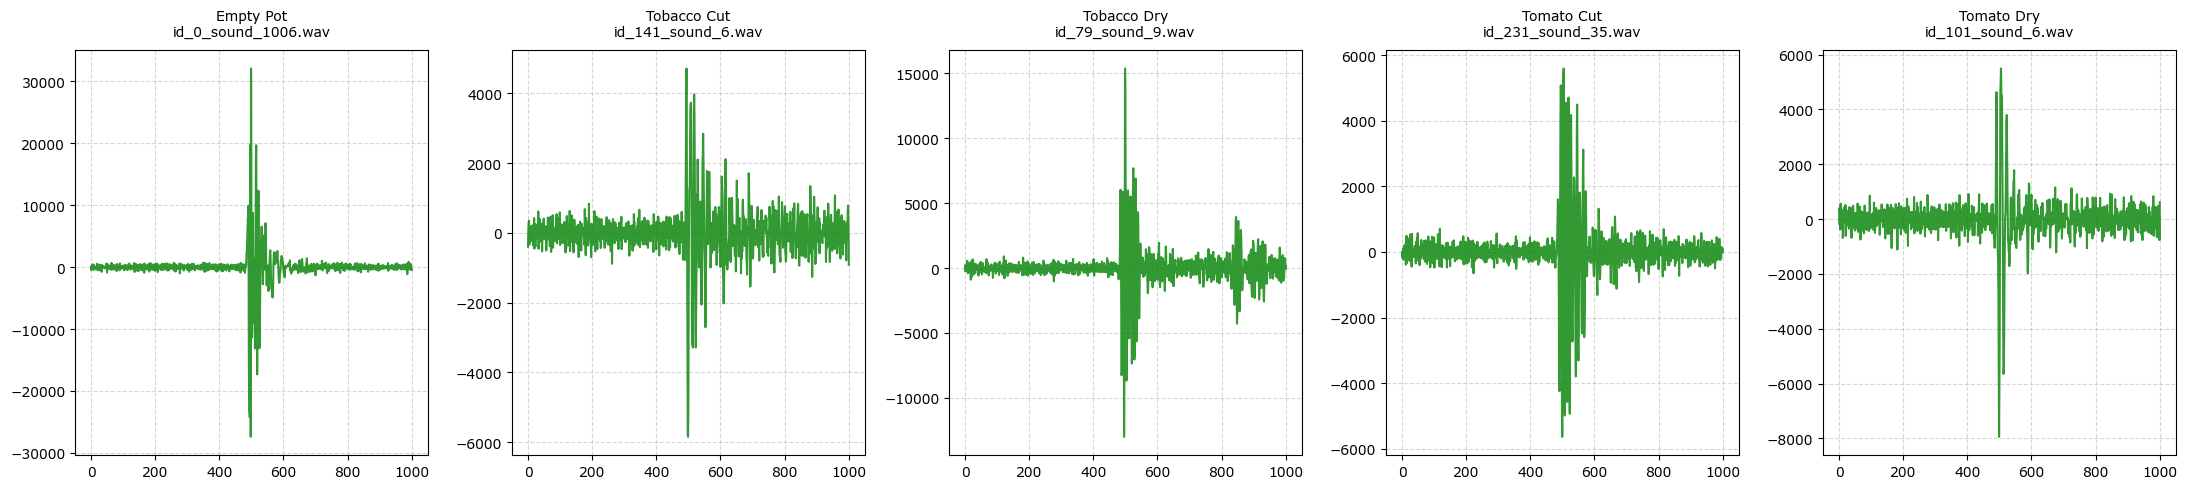

In [18]:
import random
import matplotlib.pyplot as plt

print("--- VISUALIZING RANDOM BIOLOGICAL SAMPLES ---")

fig, axes = plt.subplots(1, len(folders), figsize=(22, 5))

for idx, folder in enumerate(folders):
    files = list(folder.glob("*.wav"))
    if not files:
        continue
        
    random_file = random.choice(files)
    
    # Read the audio
    sample_rate, data = wavfile.read(random_file)
    
    # Force mono if it happens to be stereo
    if len(data.shape) > 1:
        data = data[:, 0]
        
    # Plot the raw wave
    axes[idx].plot(data, color='green', alpha=0.8)
    axes[idx].set_title(f"{folder.name}\n{random_file.name}", fontsize=10, pad=10)
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [19]:
import numpy as np
from scipy.io import wavfile
from pathlib import Path
from tqdm import tqdm

# --- PATH CONFIGURATION ---
RAW_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\raw2\PlantSounds")
PROCESSED2_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\processed2")

# The 3 specific classes we are keeping
TARGET_FOLDERS = ["Empty Pot", "Tomato Cut", "Tomato Dry"]

def process_solanum_ultrasonic():
    print("Initializing 3-Class Solanum Ultrasonic Preprocessing...\n")
    
    if not RAW_DIR.exists():
        print(f"Error: Could not find raw directory at {RAW_DIR}")
        return
        
    total_processed = 0

    for folder_name in TARGET_FOLDERS:
        input_folder = RAW_DIR / folder_name
        
        if not input_folder.exists():
            print(f"Warning: Folder '{folder_name}' not found, skipping...")
            continue
            
        # Clean folder name: "Tomato Dry" -> "tomato_dry"
        clean_name = folder_name.lower().replace(" ", "_")
        output_folder = PROCESSED2_DIR / clean_name
        output_folder.mkdir(parents=True, exist_ok=True)
        
        wav_files = list(input_folder.glob("*.wav"))
        print(f"Processing '{clean_name}' ({len(wav_files)} files)...")
        
        for wav_path in tqdm(wav_files):
            # Read 500kHz ultrasonic audio
            sample_rate, raw_data = wavfile.read(wav_path)
            
            # Force mono if stereo
            if len(raw_data.shape) > 1:
                raw_data = raw_data[:, 0]
                
            # Cast to float32
            signal = raw_data.astype(np.float32)
            
            # Save array directly
            npy_filename = wav_path.name.replace(".wav", ".npy")
            dest_path = output_folder / npy_filename
            np.save(dest_path, signal)
            total_processed += 1
            
    print(f"\nDone! Processed {total_processed} files into: {PROCESSED2_DIR}")
    print("\nSummary of created directories:")
    for folder in sorted(PROCESSED2_DIR.iterdir()):
        if folder.is_dir():
            print(f"  - {folder.name}: {len(list(folder.glob('*.npy')))} .npy files")

if __name__ == "__main__":
    process_solanum_ultrasonic()

Initializing 3-Class Solanum Ultrasonic Preprocessing...

Processing 'empty_pot' (48 files)...


100%|██████████| 48/48 [00:00<00:00, 739.66it/s]


Processing 'tomato_cut' (660 files)...


100%|██████████| 660/660 [00:02<00:00, 284.88it/s]


Processing 'tomato_dry' (1622 files)...


100%|██████████| 1622/1622 [00:12<00:00, 133.63it/s]


Done! Processed 2330 files into: G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\processed2

Summary of created directories:
  - empty_pot: 48 .npy files
  - tomato_cut: 660 .npy files
  - tomato_dry: 1622 .npy files
